In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_BN_fix_film_identity")  

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_BN_fix_film_dentity"  #

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    ##film related parameter
    film_start_idx=6,                   # to update the backbone block at late stage on index 6 (last MBCblock of EfficientNet)
    apply_to_all_after=False,            # False: to not apply FiLM on multiple blocks, just single block with the index passed
    use_bn_affine=True,                # False: to not use learnable affine parameter of Batch Normalization instead use FiLM generated affine parameters(gamma and beta)
    freeze_backbone=True,              # True: Freeze backbone
    BN_running_state_frozen=False,
    identity_init=True, # film identity initialization instead of random
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_BN_fix_film_dentity: Fold 1 ===
[TRAIN BATCH 247] preds min=0.3007 max=12.0684 mean=6.5587var=8.0771
[TRAIN BATCH 247] loss=1445.9355
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=40.7614 | ValRMSE: 39.0851
[TRAIN BATCH 247] preds min=5.4551 max=24.1052 mean=14.4228var=21.5610
[TRAIN BATCH 247] loss=1703.7572
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=34.9557 | ValRMSE: 34.2989
[TRAIN BATCH 247] preds min=5.6876 max=37.6078 mean=22.5543var=59.9713
[TRAIN BATCH 247] loss=870.3175
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=29.6797 | ValRMSE: 30.8663
[TRAIN BATCH 247] preds min=11.3007 max=44.5912 mean=27.2598var=90.0323
[TRAIN BATCH 247] loss=455.8404
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=26.5746 | ValRMSE: 28.9445
[TRAIN BATCH 247] preds min=11.6119 max=51.4941 mean=30.3794var=107.3856
[TRAIN BATCH 247] loss=828.7964
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=25.3151 | ValRMSE: 27.9308
[TRAIN BATCH 247] preds min=9.9907 max=50.5364 mea

In [5]:

import pandas as pd
df_copy =  df.copy(deep=True)
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 27.3670 (n=1983)
Fold 2 OOF RMSE: 26.7100 (n=1983)
Fold 3 OOF RMSE: 25.6245 (n=1982)
Fold 4 OOF RMSE: 26.2137 (n=1982)
Fold 5 OOF RMSE: 26.8500 (n=1982)


### Train and Validation RMSE Curve

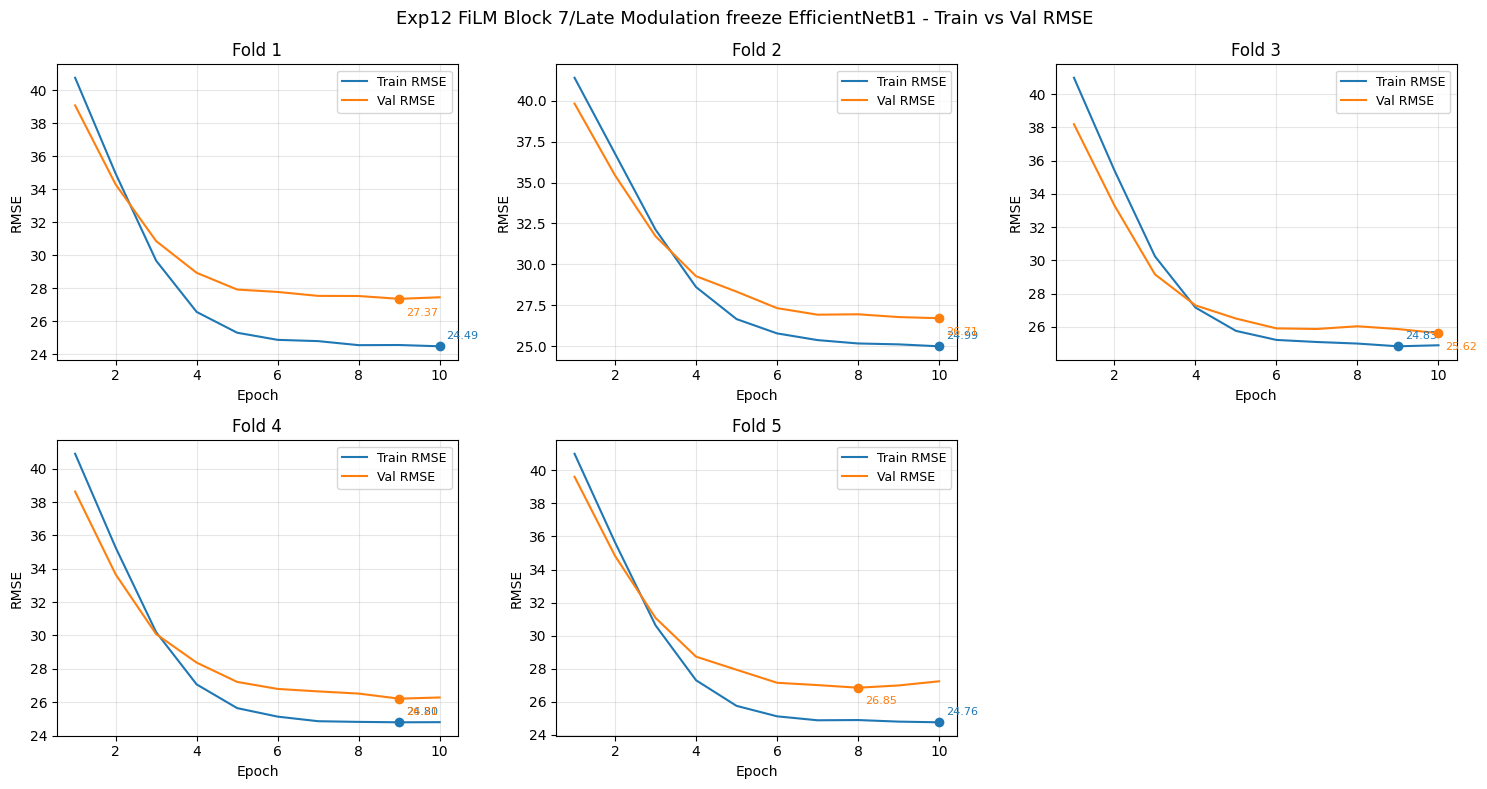

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM Block 7/Late Modulation freeze EfficientNetB1")

In [7]:
df = df_copy

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

df = df_copy
kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    identity_init=True, # film identity initialization instead of random
    ##film related parameter
    film_start_idx=6,                   # to update the backbone block at late stage on index 6 (last MBCblock of EfficientNet)
    apply_to_all_after=False,            # False: to not apply FiLM on multiple blocks, just single block with the index passed
    use_bn_affine=True,                # False: to not use learnable affine parameter of Batch Normalization instead use FiLM generated affine parameters(gamma and beta)
    freeze_backbone=True,              # True: Freeze backbone
    BN_running_state_frozen=True
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_BN_fix_film_dentity: Fold 1 ===
[TRAIN BATCH 247] preds min=-75100128.0000 max=0.3693 mean=-3004005.0000var=225601193508864.0000
[TRAIN BATCH 247] loss=225601361281024.0000
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=748052219877.1571 | ValRMSE: 182181478400.0000
[TRAIN BATCH 247] preds min=-0.0502 max=0.4572 mean=0.1491var=0.0136
[TRAIN BATCH 247] loss=2346.4763
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=1371890162137.9570 | ValRMSE: 181895593984.0000
[TRAIN BATCH 247] preds min=-0.0619 max=0.3168 mean=0.1166var=0.0076
[TRAIN BATCH 247] loss=1676.5985
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=732219831170.4500 | ValRMSE: 176555114496.0000
[TRAIN BATCH 247] preds min=-0.0537 max=4404435968.0000 mean=176283664.0000var=775923500295651328.0000
[TRAIN BATCH 247] loss=775962464238960640.0000
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=126526733716.0756 | ValRMSE: 176699441152.0000
[TRAIN BATCH 247] preds min=-0.0833 max=0.2758 mean=0.1258